# Assignment 1: Uncertainty and Sentiment in SEC Filings

Jonas Wu | NetID: jw9452

FRE-GY 7871 A, Fall 2026. This notebook reconstructs all seven required exhibits. Read `METHODS.md` for definitions and `AI_USE.md` for assistance disclosure. Download data with scripts 00–03 first; data are intentionally excluded from submission.

## Method and execution

Both Negative and Uncertainty are scored as token fractions and as sums of Loughran–McDonald (2011), equation (1): `(1+ln(tf))/(1+ln(total/distinct))*ln(N/df)`. N and df use the common final regression corpus. This retrospective IDF is not an out-of-sample predictor. Day 0 is the first NYSE session closing after acceptance, with actual early closes. Four-day excess return is the difference of compounded stock and SPY returns on [0,3]. Annualised realised volatility uses [-60,-6] and [1,63]. Complete windows are required. Aggregate trends include calendar-quarter seasonality and HAC(4); panel inference clusters by firm and filing quarter. The two-way covariance estimate is used as computed, without replacing negative diagonal entries.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, HTML, Image
from src.analysis import run, RESULTS
tables, audit = run()
def show(name, digits=5):
    display(HTML(tables[name].to_html(index=False, float_format=lambda x: f'{x:.{digits}g}')))
display(audit)

D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Code Folder\7871\assignment1\src\analysis.py:150: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  return smf.ols(formula, data=data, missing="raise")

D:\Code Folder\7871\assignment1\src\analysis.py:150: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  return smf.ols(formula, data=data, missing="raise").fit(
D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Code Folder\7871\assignment1\src\analysis.py:150: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  return smf.ols(formula, data=data, missing="raise").fit(
D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.s

D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Miniconda\envs\fr

D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Miniconda\envs\fre7871-assignment1\Lib\site-packages\statsmodels\regression\linear_model.py:2121: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
D:\Miniconda\envs\fr

{
  "snapshot_positions": 226,
  "snapshot_securities": 130,
  "holding_status_counts": {
    "domestic_filer": 92,
    "no_10x_filings": 31,
    "fund_holding": 4,
    "no_verified_sec_match": 3
  },
  "cik_matches": 123,
  "domestic_filers": 92,
  "eligible_unique_ciks": 91,
  "eligible_filings": 1683,
  "day0_moved_before_market_filters": 944,
  "day0_moved_final": 543,
  "final_filings": 1002,
  "final_firms": 60,
  "negative_words": 2355,
  "uncertainty_words": 297,
  "lexicon_overlap": 40,
  "total_final_tokens": 25838824,
  "forms": {
    "10-Q": 754,
    "10-K": 248
  },
  "dictionary_vintage": "Downloaded from the starter repository's specified URL"
}


{'snapshot_positions': 226,
 'snapshot_securities': 130,
 'holding_status_counts': {'domestic_filer': 92,
  'no_10x_filings': 31,
  'fund_holding': 4,
  'no_verified_sec_match': 3},
 'cik_matches': 123,
 'domestic_filers': 92,
 'eligible_unique_ciks': 91,
 'eligible_filings': 1683,
 'day0_moved_before_market_filters': 944,
 'day0_moved_final': 543,
 'final_filings': 1002,
 'final_firms': 60,
 'negative_words': 2355,
 'uncertainty_words': 297,
 'lexicon_overlap': 40,
 'total_final_tokens': 25838824,
 'forms': {'10-Q': 754, '10-K': 248},
 'dictionary_vintage': "Downloaded from the starter repository's specified URL"}

## Table 1. Sample construction

I retain the snapshot's original security codes and identifiers when matching issuers. Airbus and AAR share the ticker AIR in different markets. Discovery's DSY and Dassault's DSY FP also require separate records. The holding audit lists each excluded security and its evidence. I count missing prices before applying the USD 3 threshold. The word-count and market filters are research choices; the filing waterfall reports them in the order applied.

In [2]:
display(tables['table1_holdings'].groupby('status').size().rename('securities'))
show('table1_excluded_holdings')
show('table1_waterfall')

status
domestic_filer           92
fund_holding              4
no_10x_filings           31
no_verified_sec_match     3
Name: securities, dtype: int64

raw_ticker,identifier,ark_name,ticker,cik,sec_name,resolution,evidence,observed_forms,funds,n_10k,n_10q,status
2618,BNMBPD9,JD LOGISTICS INC,2618,,,no_verified_sec_match,https://www.sec.gov/Archives/edgar/data/1549802/000119312521043418/d131620dex991.htm,,ARKX,0,0,no_verified_sec_match
4689,6084848,LY CORP,4689,,,no_verified_sec_match,https://www2.jpx.co.jp/tseHpFront/StockSearch.do?callJorEFlg=1&topSearchStr=4689,,ARKF,0,0,no_verified_sec_match
6301,6496584,KOMATSU LTD,6301,0000056594,KOMATSU LTD,verified,https://data.sec.gov/submissions/CIK0000056594.json,,ARKX,0,0,no_10x_filings
ADYEN,BZ1HM42,ADYEN NV,ADYEN,0001788707,Adyen N.V./ADR,verified,https://data.sec.gov/submissions/CIK0001788707.json,"F-6 POS, F-6EF, SC 13G, SCHEDULE 13G/A",ARKF,0,0,no_10x_filings
AIR,4012250,AIRBUS SE,AIR,0001697546,AIRBUS SE,verified,https://data.sec.gov/submissions/CIK0001697546.json,D,ARKX,0,0,no_10x_filings
ALMR,010911105,ALAMAR BIOSCIENCES INC,ALMR,0002104204,"Alamar Biosciences, Inc.",verified,https://data.sec.gov/submissions/CIK0002104204.json,,ARKG,0,0,no_10x_filings
ARKY,00214Q724,ARK ACTIVE AUTOCALL INC ETF,ARKY,,,fund_holding,Frozen holdings: fund security; outside operating-company sample,,ARKK,0,0,fund_holding
BABA,01609W102,ALIBABA GROUP HOLDING-SP ADR,BABA,0001577552,Alibaba Group Holding Ltd,verified,https://data.sec.gov/submissions/CIK0001577552.json,"13F-HR, 144, 20-F, 20-F/A, 424B2, 424B3, 424B5, 6-K, CORRESP, EFFECT, F-3ASR, F-4, F-6EF, FWP, IRANNOTICE, N-PX, S-8, SC 13D/A, SC 13G, SC 13G/A, SCHEDULE 13G/A, SD, UPLOAD",ARKF,0,0,no_10x_filings
BIDU,056752108,BAIDU INC - SPON ADR,BIDU,0001329099,"Baidu, Inc.",verified,https://data.sec.gov/submissions/CIK0001329099.json,"144, 144/A, 20-F, 424B2, 424B5, 6-K, CORRESP, F-3ASR, FWP, S-8, SC 13D/A, SC 13G, SC 13G/A, SCHEDULE 13G/A, UPLOAD",ARKQ,0,0,no_10x_filings
BLSH,G16910120,BULLISH,BLSH,0001872195,Bullish,verified,https://data.sec.gov/submissions/CIK0001872195.json,"424B4, 425, 6-K, 8-A12B, CERT, CORRESP, DRS, DRS/A, DRSLTR, EFFECT, F-1, F-1/A, F-4, F-4/A, RW, S-8, SCHEDULE 13D, SCHEDULE 13G, UPLOAD",ARKF|ARKK|ARKW,0,0,no_10x_filings


stage,remaining,removed
Eligible SEC filings in 2021-2025,1683,0
Downloaded and parsed,1683,0
Unique accession,1663,20
Required forms and filing dates,1663,0
"At least 2,000 parsed tokens (both forms)",1663,0
Observed acceptance and tradable day 0,1663,0
Unambiguous exact-filing cover-page shares,1070,593
Observed unadjusted previous-session close,1053,17
Unadjusted previous-session close at least USD 3,1007,46
Complete four-day stock and SPY returns,1007,0


## Table 2. Summary statistics, by form

Proportional scores are fractions; tf.idf scores are summed weights. The correlation matrix shows both category overlap and agreement between weighting schemes.

In [3]:
show('table2_summary')
show('table2_correlations')

form,measure,count,mean,std,min,25%,50%,75%,max
10-K,Negative_proportional,248,0.024664,0.0037473,0.015819,0.021925,0.024975,0.027374,0.035103
10-K,Negative_tfidf,248,175.66,67.835,74.527,124.25,153.61,224.36,365.19
10-K,Uncertainty_proportional,248,0.020802,0.0025528,0.014154,0.019074,0.020975,0.02265,0.027948
10-K,Uncertainty_tfidf,248,28.752,9.7703,12.194,21.383,26.462,34.147,60.403
10-Q,Negative_proportional,754,0.019708,0.0096134,0.0046556,0.011775,0.016103,0.028734,0.041467
10-Q,Negative_tfidf,754,66.58,71.101,3.767,17.463,30.267,104.98,303.23
10-Q,Uncertainty_proportional,754,0.018423,0.0064409,0.0063033,0.013688,0.016603,0.024028,0.035802
10-Q,Uncertainty_tfidf,754,11.906,8.4644,1.4991,5.6687,9.3335,14.893,43.414


form,measure_a,measure_b,correlation
10-K,Negative_proportional,Negative_proportional,1
10-K,Negative_proportional,Negative_tfidf,0.5608
10-K,Negative_proportional,Uncertainty_proportional,0.73607
10-K,Negative_proportional,Uncertainty_tfidf,0.33996
10-K,Negative_tfidf,Negative_proportional,0.5608
10-K,Negative_tfidf,Negative_tfidf,1
10-K,Negative_tfidf,Uncertainty_proportional,0.36144
10-K,Negative_tfidf,Uncertainty_tfidf,0.87871
10-K,Uncertainty_proportional,Negative_proportional,0.73607
10-K,Uncertainty_proportional,Negative_tfidf,0.36144


## Table 3. The thirty most frequent words in each list

The denominator is all occurrences in that category, not only its top thirty words. Ties are ordered alphabetically.

In [4]:
show('table3_words')

category,rank,word,count,share_pct
Negative,1,LOSS,31994,4.8917
Negative,2,ADVERSELY,26329,4.0256
Negative,3,ADVERSE,21486,3.2851
Negative,4,CLAIMS,17993,2.7511
Negative,5,AGAINST,14374,2.1977
Negative,6,UNABLE,14176,2.1675
Negative,7,LOSSES,13624,2.0831
Negative,8,FAILURE,13227,2.0224
Negative,9,HARM,11845,1.8111
Negative,10,LITIGATION,11193,1.7114


## Figure 1. Quarterly measures and VIX

Each firm-form-quarter receives one vote. Solid lines split forms. Dashed lines remove firm-form baseline means and add the common mean; they illustrate composition but are not balanced-panel estimates. The within-firm fixed-effect regressions below provide the primary trend test.

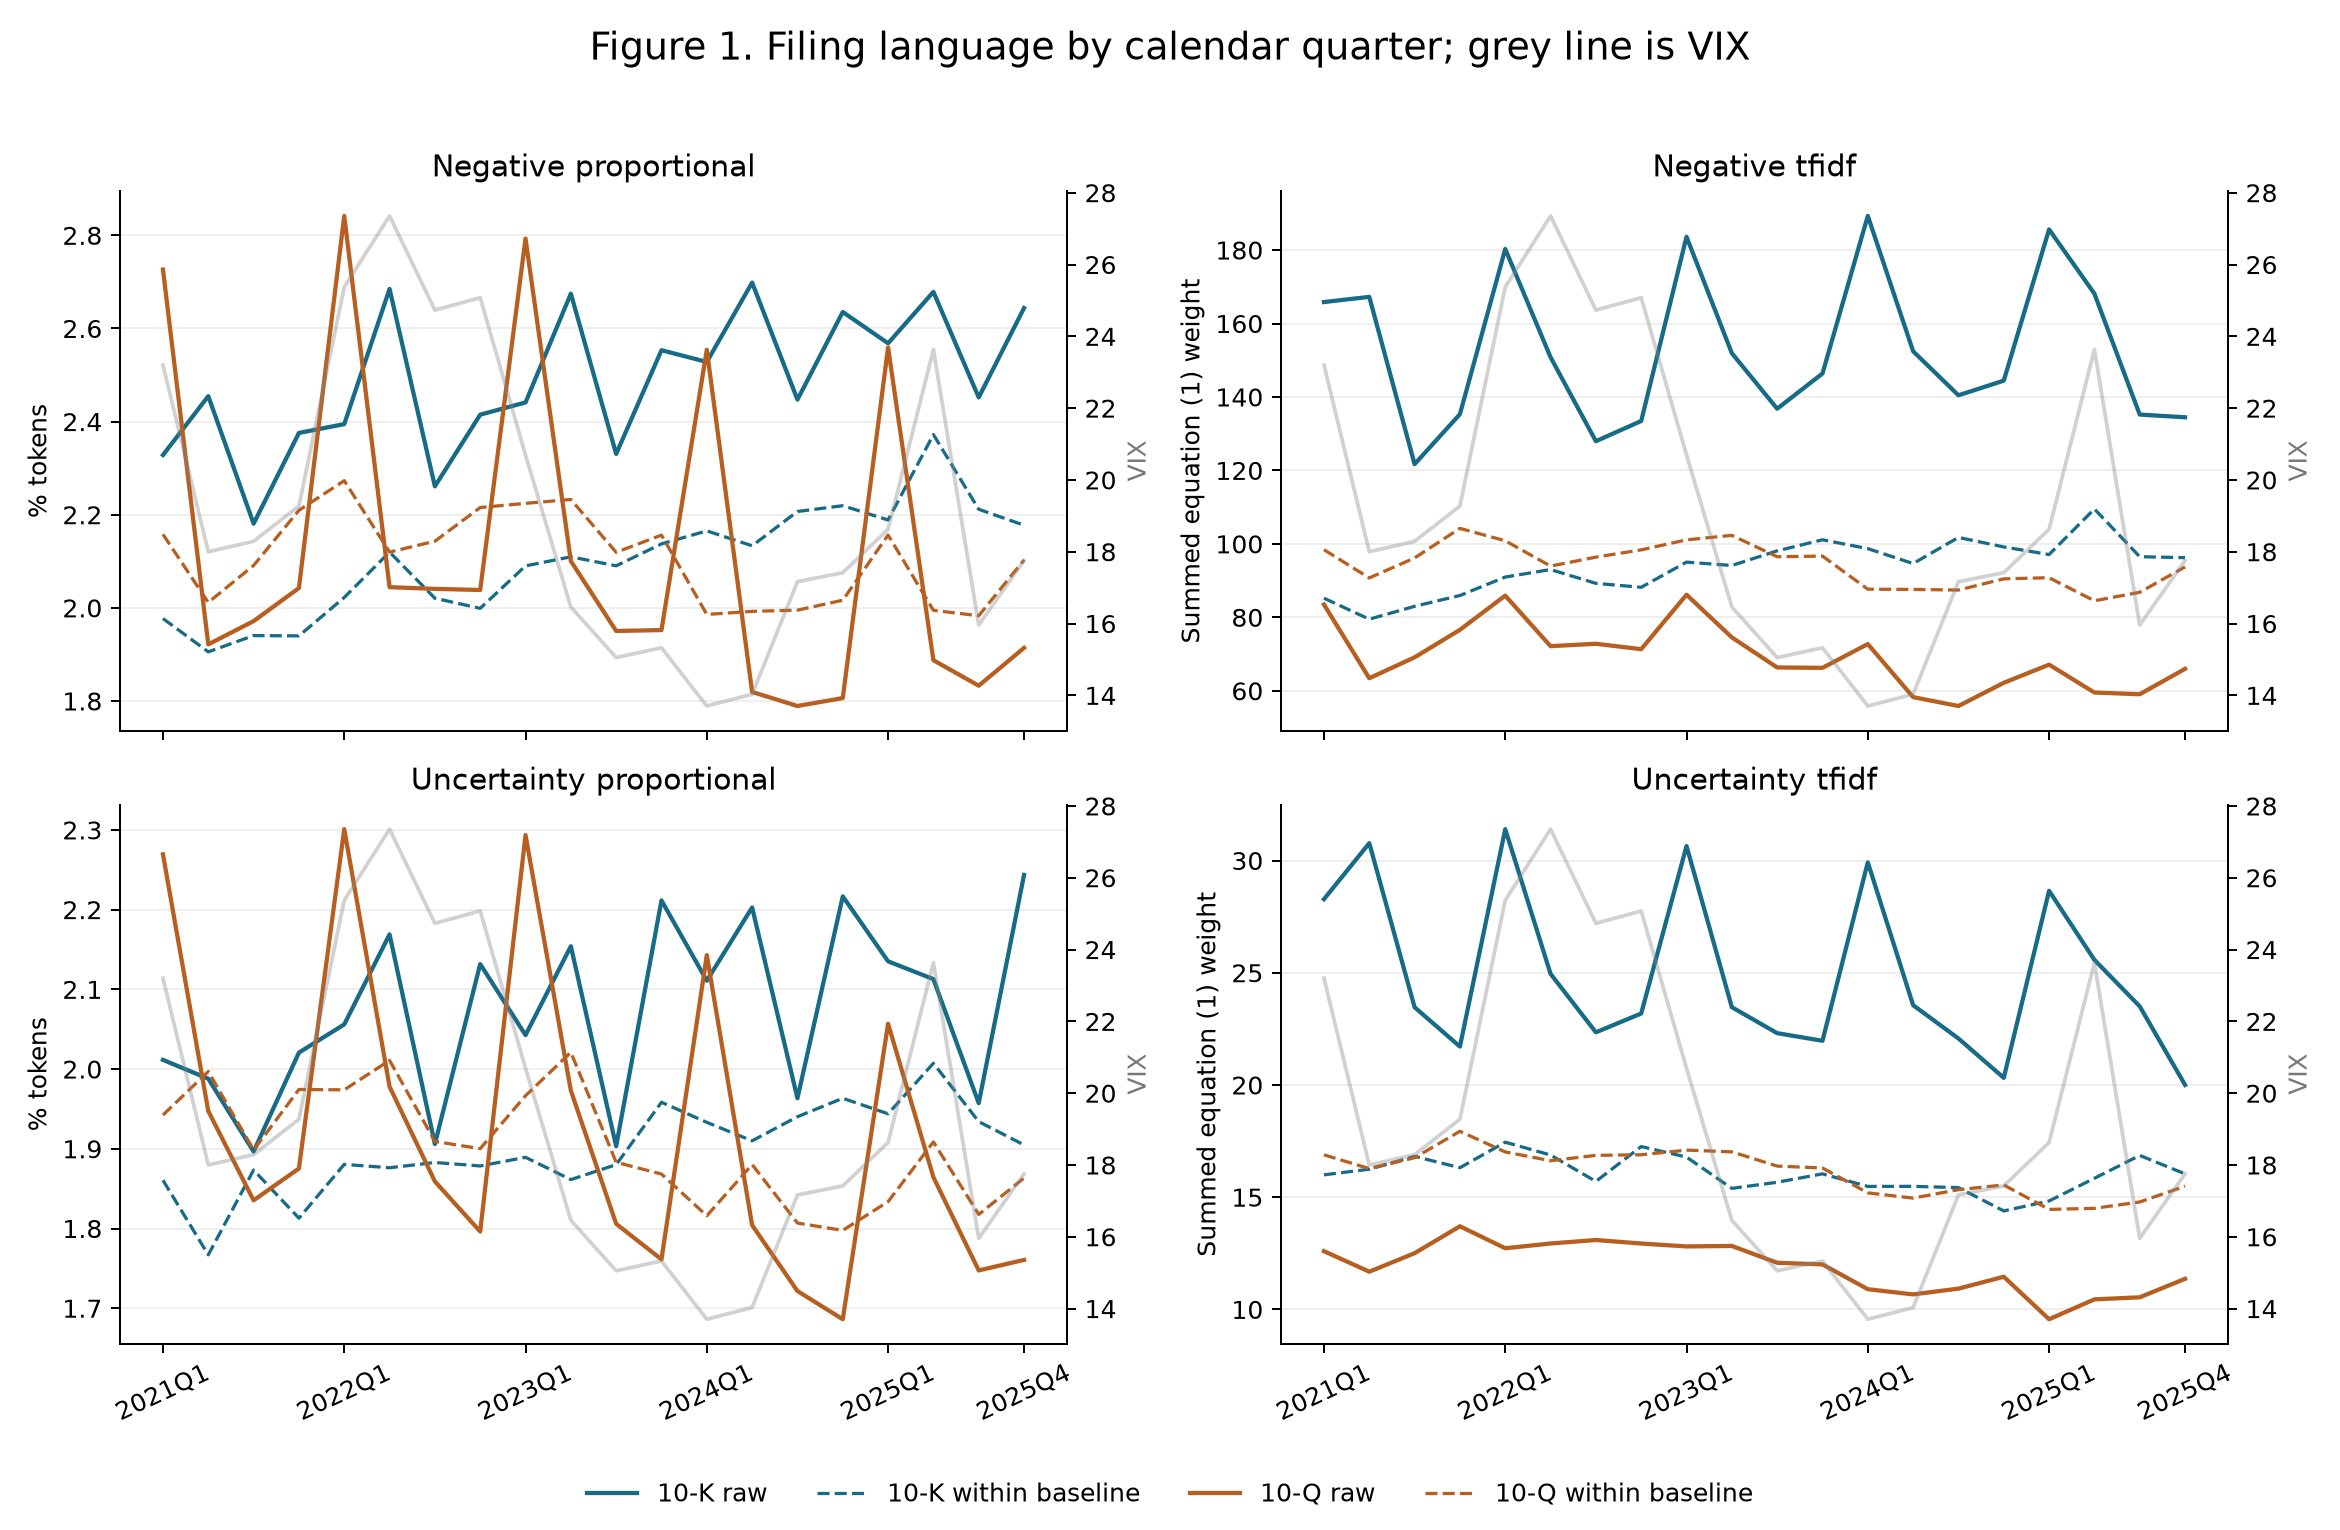

In [5]:
display(Image(filename=str(RESULTS / 'figure1.png')))

## Table 4. Aggregate and within-firm trends

Quarterly time runs from 0 to 19. Aggregate estimates control for season-of-year and compare conventional OLS with Newey–West lag 4. Panel estimates include firm-form fixed effects and seasonality; covariance clusters on firm and filing quarter. Twenty quarters limit aggregate inference even when there are many filings.

In [6]:
show('table4_trends')

form,measure,specification,covariance,term,coefficient,se,t,p,ci_low,ci_high,n,r_squared
10-K,Negative_proportional,Aggregate + calendar-quarter seasonality,OLS,time,0.00016002,1.873e-05,8.5435,3.7979e-07,0.0001201,0.00019994,20,0.92377
10-K,Negative_proportional,Aggregate + calendar-quarter seasonality,Newey-West lag 4,time,0.00016002,1.8149e-05,8.817,2.5491e-07,0.00012134,0.0001987,20,0.92377
10-K,Negative_tfidf,Aggregate + calendar-quarter seasonality,OLS,time,0.62943,0.28069,2.2424,0.040473,0.031149,1.2277,20,0.90732
10-K,Negative_tfidf,Aggregate + calendar-quarter seasonality,Newey-West lag 4,time,0.62943,0.17489,3.5991,0.0026306,0.25667,1.0022,20,0.90732
10-K,Uncertainty_proportional,Aggregate + calendar-quarter seasonality,OLS,time,8.0936e-05,1.8593e-05,4.3529,0.00056807,4.1305e-05,0.00012057,20,0.86172
10-K,Uncertainty_proportional,Aggregate + calendar-quarter seasonality,Newey-West lag 4,time,8.0936e-05,1.8432e-05,4.391,0.00052632,4.1649e-05,0.00012022,20,0.86172
10-K,Uncertainty_tfidf,Aggregate + calendar-quarter seasonality,OLS,time,-0.11882,0.066481,-1.7873,0.094105,-0.26052,0.022878,20,0.83473
10-K,Uncertainty_tfidf,Aggregate + calendar-quarter seasonality,Newey-West lag 4,time,-0.11882,0.04389,-2.7073,0.01622,-0.21237,-0.025273,20,0.83473
10-Q,Negative_proportional,Aggregate + calendar-quarter seasonality,OLS,time,-0.00012082,3.4053e-05,-3.548,0.0029213,-0.0001934,-4.8237e-05,20,0.95246
10-Q,Negative_proportional,Aggregate + calendar-quarter seasonality,Newey-West lag 4,time,-0.00012082,4.112e-05,-2.9383,0.010173,-0.00020846,-3.3176e-05,20,0.95246


## Table 5. Uncertainty and subsequent-quarter volatility

Dependent variable: log annualised post-filing volatility. Tone regressors are standardised once on the common sample. Both versions use identical observations and controls: log size, log pre-filing turnover, log word count, pre-filing excess return, form and quarter effects. Compare the uncertainty coefficient before and after adding log pre-volatility. The relationship is conditional association, not causal evidence.

In [7]:
show('table5_volatility')

table,form,weighting,pre_vol_control,covariance,formula,term,coefficient,se,t,p,ci_low,ci_high,n,r_squared
Table 5,Pooled,proportional,False,Firm and quarter clusters,log_post_vol ~ Uncertainty_proportional_z + log_size + log_turnover + log_words + pre_return + C(form) + C(quarter),Uncertainty_proportional_z,0.10427,0.041453,2.5154,0.021047,0.017507,0.19103,1002,0.62581
Table 5,Pooled,proportional,True,Firm and quarter clusters,log_post_vol ~ Uncertainty_proportional_z + log_size + log_turnover + log_words + pre_return + C(form) + C(quarter) + log_pre_vol,Uncertainty_proportional_z,0.04424,0.018528,2.3878,0.027495,0.005461,0.083019,1002,0.75948
Table 5,Pooled,tfidf,False,Firm and quarter clusters,log_post_vol ~ Uncertainty_tfidf_z + log_size + log_turnover + log_words + pre_return + C(form) + C(quarter),Uncertainty_tfidf_z,0.083827,0.057289,1.4632,0.15975,-0.036081,0.20373,1002,0.61244
Table 5,Pooled,tfidf,True,Firm and quarter clusters,log_post_vol ~ Uncertainty_tfidf_z + log_size + log_turnover + log_words + pre_return + C(form) + C(quarter) + log_pre_vol,Uncertainty_tfidf_z,0.040202,0.02409,1.6688,0.11155,-0.010219,0.090624,1002,0.75734
Table 5,10-K,proportional,False,Firm and quarter clusters,log_post_vol ~ Uncertainty_proportional_z + log_size + log_turnover + log_words + pre_return + C(quarter),Uncertainty_proportional_z,0.14982,0.074125,2.0211,0.057585,-0.0053293,0.30496,248,0.64797
Table 5,10-K,proportional,True,Firm and quarter clusters,log_post_vol ~ Uncertainty_proportional_z + log_size + log_turnover + log_words + pre_return + C(quarter) + log_pre_vol,Uncertainty_proportional_z,0.069504,0.069796,0.99582,0.33185,-0.076581,0.21559,248,0.79596
Table 5,10-K,tfidf,False,Firm and quarter clusters,log_post_vol ~ Uncertainty_tfidf_z + log_size + log_turnover + log_words + pre_return + C(quarter),Uncertainty_tfidf_z,0.14199,0.065789,2.1583,0.043912,0.0042929,0.27969,248,0.64589
Table 5,10-K,tfidf,True,Firm and quarter clusters,log_post_vol ~ Uncertainty_tfidf_z + log_size + log_turnover + log_words + pre_return + C(quarter) + log_pre_vol,Uncertainty_tfidf_z,0.070753,0.036658,1.9301,0.068661,-0.0059728,0.14748,248,0.79585
Table 5,10-Q,proportional,False,Firm and quarter clusters,log_post_vol ~ Uncertainty_proportional_z + log_size + log_turnover + log_words + pre_return + C(quarter),Uncertainty_proportional_z,0.11893,0.047351,2.5116,0.021215,0.01982,0.21804,754,0.63713
Table 5,10-Q,proportional,True,Firm and quarter clusters,log_post_vol ~ Uncertainty_proportional_z + log_size + log_turnover + log_words + pre_return + C(quarter) + log_pre_vol,Uncertainty_proportional_z,0.053848,0.021928,2.4557,0.023863,0.0079524,0.099744,754,0.75998


## Table 6. Sentiment and four-day filing excess return

Power first: the approximate 80%-power minimum detectable effect is `(t_0.975, min(clusters)-1 + z_0.8) * clustered SE` for a one-SD tone change. This is a design-sensitivity calculation using estimated noise, not observed post-hoc power. The controls match Table 5 and include pre-volatility.

In [8]:
show('table6_power')
show('table6_returns')

form,weighting,n,firms,quarters,cluster_df,cluster_se,mde_80pct,interpretation
Pooled,proportional,1002,60,20,19,0.0028475,0.0083565,"Approximate 80% power, two-sided 5%, return effect per common-sample 1 SD tone"
Pooled,tfidf,1002,60,20,19,0.0075812,0.022248,"Approximate 80% power, two-sided 5%, return effect per common-sample 1 SD tone"
10-K,proportional,248,57,20,19,0.018434,0.054097,"Approximate 80% power, two-sided 5%, return effect per common-sample 1 SD tone"
10-K,tfidf,248,57,20,19,0.01491,0.043755,"Approximate 80% power, two-sided 5%, return effect per common-sample 1 SD tone"
10-Q,proportional,754,57,20,19,0.003311,0.0097167,"Approximate 80% power, two-sided 5%, return effect per common-sample 1 SD tone"
10-Q,tfidf,754,57,20,19,0.0080343,0.023578,"Approximate 80% power, two-sided 5%, return effect per common-sample 1 SD tone"


table,form,weighting,pre_vol_control,covariance,formula,term,coefficient,se,t,p,ci_low,ci_high,n,r_squared
Table 6,Pooled,proportional,True,Firm and quarter clusters,filing_return ~ Negative_proportional_z + log_pre_vol + log_size + log_turnover + log_words + pre_return + C(form) + C(quarter),Negative_proportional_z,-0.0031979,0.0028475,-1.123,0.27542,-0.0091578,0.0027621,1002,0.040497
Table 6,Pooled,tfidf,True,Firm and quarter clusters,filing_return ~ Negative_tfidf_z + log_pre_vol + log_size + log_turnover + log_words + pre_return + C(form) + C(quarter),Negative_tfidf_z,-0.004318,0.0075812,-0.56956,0.57565,-0.020186,0.01155,1002,0.040326
Table 6,10-K,proportional,True,Firm and quarter clusters,filing_return ~ Negative_proportional_z + log_pre_vol + log_size + log_turnover + log_words + pre_return + C(quarter),Negative_proportional_z,-0.0057427,0.018434,-0.31153,0.75879,-0.044325,0.03284,248,0.09071
Table 6,10-K,tfidf,True,Firm and quarter clusters,filing_return ~ Negative_tfidf_z + log_pre_vol + log_size + log_turnover + log_words + pre_return + C(quarter),Negative_tfidf_z,0.0028053,0.01491,0.18815,0.85275,-0.028401,0.034012,248,0.090394
Table 6,10-Q,proportional,True,Firm and quarter clusters,filing_return ~ Negative_proportional_z + log_pre_vol + log_size + log_turnover + log_words + pre_return + C(quarter),Negative_proportional_z,-0.0068875,0.003311,-2.0802,0.051285,-0.013818,4.2535e-05,754,0.047806
Table 6,10-Q,tfidf,True,Firm and quarter clusters,filing_return ~ Negative_tfidf_z + log_pre_vol + log_size + log_turnover + log_words + pre_return + C(quarter),Negative_tfidf_z,-0.0068705,0.0080343,-0.85514,0.40313,-0.023687,0.0099455,754,0.046653


## Company comparison

Rank issuers by mean filing-level dictionary share within each form. Count repeated occurrences, not distinct words. Show coverage without an extra minimum-filing filter. Separately rank pooled raw counts, which depend on report length and number of filings. These are descriptive rankings of the retained sample, not tests of company risk or management confidence. Company names and tickers follow the retrieved SEC metadata and need not be historical labels.

In [9]:
show('company_top5')

cik,ticker,company,form,category,filings,years,first_filing,last_filing,tokens,occurrences,mean_share_pct,pooled_share_pct,rank,ranking_metric
0001816590,CMPS,COMPASS Pathways plc,All,Negative,16,4,2022-02-24,2025-11-04,1267849,40359,3.2462,3.1833,1,occurrences
0001549595,NRIX,"Nurix Therapeutics, Inc.",All,Negative,20,5,2021-02-16,2025-10-09,1239316,38495,3.1694,3.1061,2,occurrences
0001818874,SOFI,"SoFi Technologies, Inc.",All,Negative,18,5,2021-08-16,2025-11-06,1258807,35013,2.637,2.7814,3,occurrences
0001652130,NTLA,"Intellia Therapeutics, Inc.",All,Negative,20,5,2021-02-26,2025-11-06,1023190,31300,3.1327,3.0591,4,occurrences
0001527753,PSNL,"Personalis, Inc.",All,Negative,13,5,2021-02-25,2025-11-04,689292,24930,3.6765,3.6168,5,occurrences
0001818331,WGS,GeneDx Holdings Corp.,10-K,Negative,2,2,2024-02-23,2025-02-20,107714,3451,3.2045,3.2039,1,mean_share_pct
0001527753,PSNL,"Personalis, Inc.",10-K,Negative,4,4,2021-02-25,2025-02-27,265413,8389,3.1713,3.1607,2,mean_share_pct
0001478320,ADPT,Adaptive Biotechnologies Corp,10-K,Negative,5,5,2021-02-24,2025-03-03,342491,10291,3.0156,3.0048,3,mean_share_pct
0001069258,KTOS,"KRATOS DEFENSE & SECURITY SOLUTIONS, INC.",10-K,Negative,5,5,2021-02-25,2025-02-26,234722,7074,3.0132,3.0138,4,mean_share_pct
0001217234,CDNA,"CareDx, Inc.",10-K,Negative,5,5,2021-02-24,2025-02-28,294376,8773,2.983,2.9802,5,mean_share_pct


## Full regression coefficients and reproducibility

All specifications run are saved, including nuisance controls and fixed effects, in `results/regression_all_terms.csv`. No p-value-based model selection or covariance repairs are performed. ARKK excess return is constructed but is not an additional fitted test. `REPORT.md` and the PDF interpret the actual estimates. The common complete-case sample and exclusion identifiers are local under `data/interim/`. The GitHub submission includes no downloaded data.

In [10]:
import sys, importlib.metadata as metadata
print(sys.version)
for package in ['pandas','numpy','statsmodels','pandas_market_calendars','yfinance']:
    print(package, metadata.version(package))

3.11.16 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:36:16) [MSC v.1942 64 bit (AMD64)]
pandas 3.0.5
numpy 2.4.6
statsmodels 0.15.0
pandas_market_calendars 5.4.0
yfinance 1.7.0
